In [3]:
import pandas as pd
from sklearn.cluster import KMeans

value_system_df = pd.read_csv('ESS_value_system.csv', sep=',', na_values=[''], quotechar='"')
value_system_df

,country,P__Universalism__Universalism,P__Universalism__Benevolence,P__Universalism__Tradition,P__Universalism__Conformity,P__Universalism__Security,P__Universalism__Power,P__Universalism__Achievement,P__Universalism__Hedonism,P__Universalism__Stimulation,...,VA__Achievement__lgbt_freedom,VA__Hedonism__immigration,VA__Hedonism__lgbt_adopt,VA__Hedonism__lgbt_freedom,VA__Stimulation__immigration,VA__Stimulation__lgbt_adopt,VA__Stimulation__lgbt_freedom,VA__Self-Direction__immigration,VA__Self-Direction__lgbt_adopt,VA__Self-Direction__lgbt_freedom
0,AT,0.5,0.439650,0.703219,0.722483,0.506551,0.886481,0.739598,0.675886,0.939650,...,0.092498,-0.019490,0.003466,0.011192,-0.605632,0.107690,0.347792,0.243284,-0.043259,-0.139709
1,BE,0.5,0.441426,0.625192,0.729344,0.623058,0.941426,0.760697,0.619364,0.806002,...,0.153142,0.094143,-0.037635,-0.065554,-0.320609,0.128167,0.223247,0.202117,-0.080799,-0.140739
2,BG,0.5,0.383884,0.515657,0.569200,0.370097,0.862563,0.547718,0.815913,0.870097,...,0.000359,-0.436852,-0.188757,-0.001186,-0.551861,-0.238450,-0.001498,-0.118366,-0.051144,-0.000321
3,CH,0.5,0.436856,0.678188,0.818525,0.631271,0.936856,0.803474,0.620891,0.839388,...,0.177381,0.125697,-0.025510,-0.079617,-0.359852,0.073031,0.227934,0.374123,-0.075927,-0.236973
4,CY,0.5,0.469638,0.555685,0.774096,0.470995,0.969638,0.849096,0.850840,0.946770,...,0.055972,-0.312418,-0.140931,0.056618,-0.508189,-0.229243,0.092096,0.218342,0.098494,-0.039569
5,CZ,0.5,0.476553,0.631114,0.633514,0.347979,0.760106,0.804251,0.710534,0.847979,...,0.135815,-0.196912,-0.036753,0.066993,-0.493587,-0.092127,0.167926,0.298447,0.055705,-0.101536
6,DE,0.5,0.444972,0.674311,0.797968,0.603134,0.944972,0.815892,0.680148,0.867855,...,0.187007,0.014926,-0.005259,-0.009735,-0.402200,0.141715,0.262320,0.327713,-0.115470,-0.213739
7,DK,0.5,0.397001,0.692553,0.647044,0.647819,0.897001,0.798052,0.591105,0.782451,...,0.248563,0.127449,-0.050432,-0.095295,-0.297765,0.117826,0.222642,0.259802,-0.102804,-0.194256
8,EE,0.5,0.475068,0.676732,0.707775,0.535074,0.975068,0.847738,0.764238,0.865301,...,0.065024,-0.158790,-0.046629,0.029985,-0.383374,-0.112578,0.072394,0.248783,0.073055,-0.046979
9,ES,0.5,0.472482,0.607461,0.706610,0.549163,0.972482,0.867887,0.724482,0.846440,...,0.283055,-0.092816,0.050820,0.063846,-0.363833,0.199209,0.250271,0.227940,-0.124804,-0.156794


In [5]:
abstracted_system_df = pd.read_csv('ESS_ABSTRACTED_value_system.csv', sep=',', na_values=[''], quotechar='"')
abstracted_system_df

,country,P__Self-Transcendence__Self-Transcendence,P__Self-Transcendence__Conservation,P__Self-Transcendence__Self-Enhancement,P__Self-Transcendence__Openness to Change,P__Conservation__Self-Transcendence,P__Conservation__Conservation,P__Conservation__Self-Enhancement,P__Conservation__Openness to Change,P__Self-Enhancement__Self-Transcendence,...,VA__Self-Transcendence__lgbt_freedom,VA__Conservation__immigration,VA__Conservation__lgbt_adopt,VA__Conservation__lgbt_freedom,VA__Self-Enhancement__immigration,VA__Self-Enhancement__lgbt_adopt,VA__Self-Enhancement__lgbt_freedom,VA__Openness to Change__immigration,VA__Openness to Change__lgbt_adopt,VA__Openness to Change__lgbt_freedom
0,AT,0.5,0.793474,1.000000,0.927830,0.206526,0.5,0.706526,0.634356,0.000000,...,-0.467254,0.031605,-0.005639,-0.018138,-0.519131,0.092617,0.297918,-0.326677,0.058282,0.187473
1,BE,0.5,0.810120,1.000000,0.820627,0.189880,0.5,0.689880,0.510506,0.000000,...,-0.522517,-0.073156,0.029211,0.050708,-0.579502,0.231390,0.401681,-0.101173,0.040398,0.070128
2,BG,0.5,0.562267,0.938276,1.000000,0.437733,0.5,0.876009,0.937733,0.061724,...,0.002290,0.477714,0.207274,0.001720,-0.478405,-0.207574,-0.001723,-0.635356,-0.275673,-0.002288
3,CH,0.5,0.878259,1.000000,0.795216,0.121741,0.5,0.621741,0.416958,0.000000,...,-0.495545,-0.226373,0.045987,0.143392,-0.551017,0.111938,0.349032,-0.004927,0.001001,0.003121
4,CY,0.5,0.642504,1.000000,0.884290,0.357496,0.5,0.857496,0.741786,0.000000,...,-0.113924,0.279654,0.126152,-0.050680,-0.595828,-0.268777,0.107978,-0.312463,-0.140951,0.056626
5,CZ,0.5,0.591490,1.000000,0.855354,0.408510,0.5,0.908510,0.763864,0.000000,...,-0.208074,0.375549,0.070674,-0.127653,-0.680879,-0.128133,0.231437,-0.306817,-0.057739,0.104290
6,DE,0.5,0.821371,1.000000,0.827151,0.178629,0.5,0.678629,0.505780,0.000000,...,-0.499138,-0.091308,0.032138,0.059523,-0.567652,0.199801,0.370045,-0.106722,0.037564,0.069570
7,DK,0.5,0.840578,1.000000,0.797471,0.159422,0.5,0.659422,0.456892,0.000000,...,-0.568228,-0.149510,0.059155,0.111975,-0.574634,0.227359,0.430372,-0.034556,0.013672,0.025880
8,EE,0.5,0.703212,1.000000,0.832313,0.296788,0.5,0.796788,0.629101,0.000000,...,-0.130102,0.148451,0.043650,-0.027977,-0.642983,-0.189061,0.121175,-0.195818,-0.057578,0.036903
9,ES,0.5,0.682532,1.000000,0.812867,0.317468,0.5,0.817468,0.630334,0.000000,...,-0.457781,0.176846,-0.097337,-0.121997,-0.669734,0.368625,0.462013,-0.170712,0.093961,0.117765


## Notes

- "Immigration" means "Immigration bad or good for country's economy", where a higher value means **good**.
- "lgbt_freedom" means "Gay men and lesbians should be free to live life as they wish", where a higher value means **yes**
- "lgbt_adopt" means "Gay men and lesbians should have the same rights to adopt children as straight couples", where a higher value means **yes**

- If no country is specified, plots are over **all** countries

## Step 1: Understand the relationship of action judgements
- An action judgement states: If the action is taken, then to what extent will my value be promoted or demoted? (In the opinion of the agent)

### Key Conclusions
- Polarising actions have very strong, differing promotion and demotion between agents. We can see that Immigration is the most polarising action.

- Over all agents, "Immigration" shows a medium-strength correlation between certain values and actions. There are more extreme views portrayed, showing an increased level of polarisation.
- For LGBT rights and adoption, there is no strong correlation between actions and values. There is no overall trend, and the actions are not very polarising.

In [6]:
# Find all columns that start with "P__"
pref_cols = pd.DataFrame(value_system_df.filter(regex="^P__"))
# Remove all cols that have the same two values (P__Universalism__Universalism, P__Benevolence__Benevolence, etc.)
for col in pref_cols.columns:
    col_split = col.split("__")
    if len(col_split) == 3 and col_split[1] == col_split[2]:
        pref_cols = pref_cols.drop(col, axis=1)
    else:
        # Not dropped, so drop the symmetrical col (P__A__B == P__B__A)
        symmetrical_col = "P__"+ col_split[2] + "__" + col_split[1]
        if col in pref_cols.columns:
            pref_cols = pref_cols.drop(columns=[symmetrical_col], axis=1)

abstracted_pref_cols = pd.DataFrame(abstracted_system_df.filter(regex="^P__"))
# Remove all cols that have the same two values (P__Universalism__Universalism, P__Benevolence__Benevolence, etc.)
for col in abstracted_pref_cols.columns:
    col_split = col.split("__")
    if len(col_split) == 3 and col_split[1] == col_split[2]:
        abstracted_pref_cols = abstracted_pref_cols.drop(col, axis=1)
    else:
        # Not dropped, so drop the symmetrical col (P__A__B == P__B__A)
        symmetrical_col = "P__"+ col_split[2] + "__" + col_split[1]
        if col in abstracted_pref_cols.columns:
            abstracted_pref_cols = abstracted_pref_cols.drop(columns=[symmetrical_col], axis=1)

In [3]:
stds = pref_cols.std()
stds = stds.sort_values(ascending=True)
print("Standard Deviations for each comparison: \n", stds)

Standard Deviations for each comparison: 
 P__Universalism__Benevolence       0.033759
P__Universalism__Self-Direction    0.041197
P__Universalism__Stimulation       0.052320
P__Benevolence__Self-Direction     0.054438
P__Benevolence__Stimulation        0.054482
P__Conformity__Power               0.058033
P__Stimulation__Self-Direction     0.059965
P__Universalism__Tradition         0.062781
P__Tradition__Security             0.063166
P__Universalism__Power             0.065508
P__Tradition__Achievement          0.065853
P__Power__Self-Direction           0.067815
P__Tradition__Power                0.069179
P__Tradition__Conformity           0.069932
P__Universalism__Conformity        0.071217
P__Security__Power                 0.075887
P__Benevolence__Power              0.076688
P__Conformity__Achievement         0.077470
P__Power__Achievement              0.078639
P__Benevolence__Conformity         0.078673
P__Benevolence__Tradition          0.079432
P__Security__Achievement         

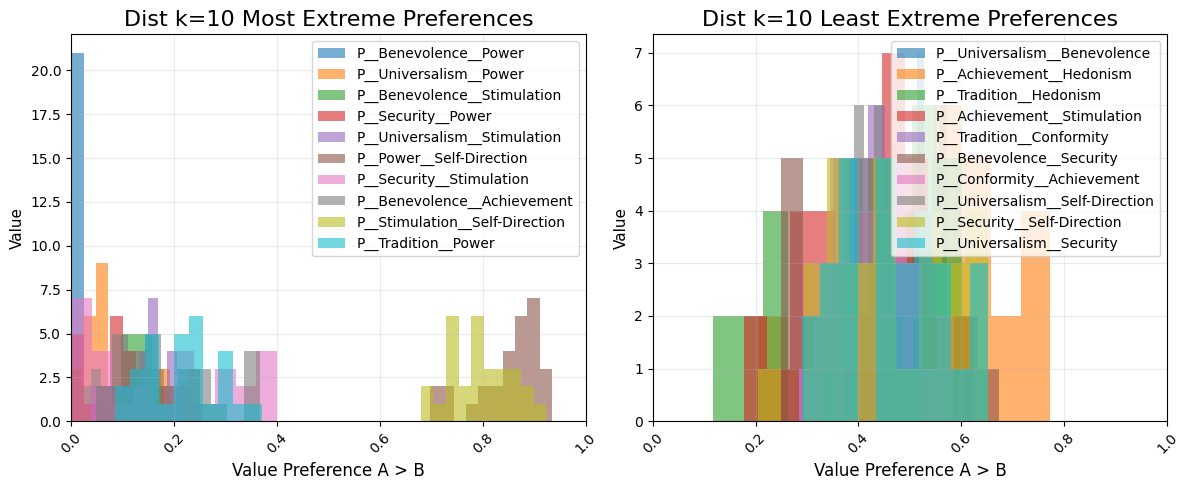

In [4]:
# There are 45 pairwise comparisons, look at top 10 for each (most nothing, most strong)
import matplotlib.pyplot as plt
k = 10
# Find cols that have a mean closest to 0 or 1, find the absolute difference to either 0 or 1 (depending on which side of 0.5 they're on), and then rank the distances
high_means = pref_cols.mean(axis=0).sort_values(ascending=False)
low_means = pref_cols.mean(axis=0).sort_values(ascending=True)
# Clip values
high_means = high_means.clip(lower=0.5, upper=1.0)
low_means = low_means.clip(lower=0.0, upper=0.5)
# Find diff
high_means = 1 - high_means
# Concat
means = pd.concat([high_means, low_means])
means = means.sort_values(ascending=True)

means_keys_high = means.keys().tolist()[:k]
#print("High keys: ", means_keys_high)
means = means.sort_values(ascending=False)
means_keys_low = means.keys().tolist()[:k]
#print("Low keys: ", means_keys_low)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={"width_ratios": [1, 1]})

for col in means_keys_high:
    pref_cols.hist(col, bins=10, alpha=0.6, label=col, ax=axes[0])
axes[0].set_title(f"Dist k={k} Most Extreme Preferences", fontsize=16)
axes[0].set_xlabel('Value Preference A > B', fontsize=12)
axes[0].set_ylabel('Frequency Amongst Agents', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].set_ylabel("Value", fontsize=11)
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(alpha=0.25)
axes[0].set_xlim(0, 1)

for col in means_keys_low:
    pref_cols.hist(col, bins=10, alpha=0.6, label=col, ax=axes[1])
axes[1].set_title(f"Dist k={k} Least Extreme Preferences", fontsize=16)
axes[1].set_xlabel('Value Preference A > B', fontsize=12)
axes[1].set_ylabel('Frequency Amongst Agents', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].set_ylabel("Value", fontsize=11)
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(alpha=0.25)
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.show()


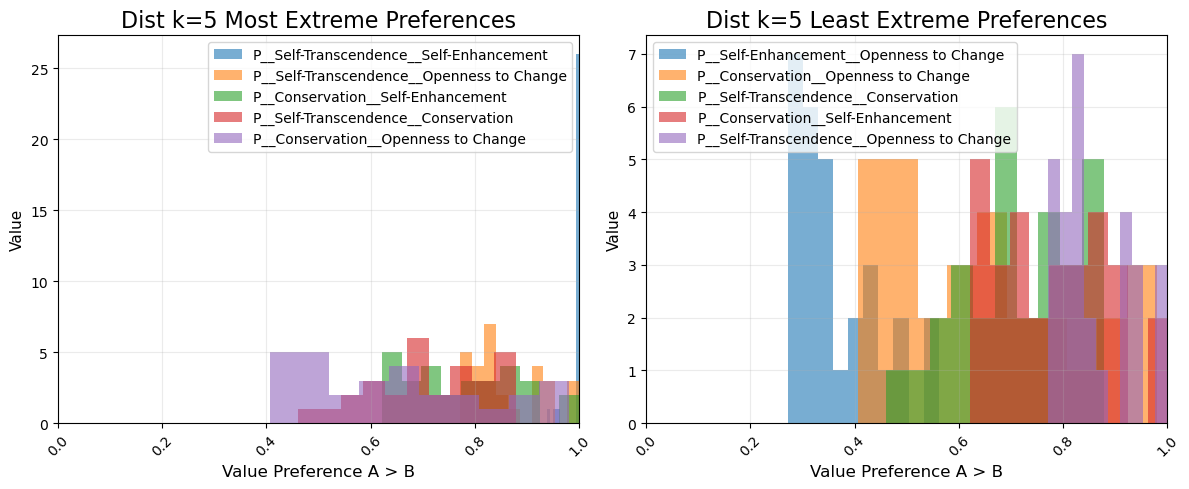

In [7]:
# There are 45 pairwise comparisons, look at top 10 for each (most nothing, most strong)
import matplotlib.pyplot as plt
k = 5
# Find cols that have a mean closest to 0 or 1, find the absolute difference to either 0 or 1 (depending on which side of 0.5 they're on), and then rank the distances
high_means = abstracted_pref_cols.mean(axis=0).sort_values(ascending=False)
low_means = abstracted_pref_cols.mean(axis=0).sort_values(ascending=True)
# Clip values
high_means = high_means.clip(lower=0.5, upper=1.0)
low_means = low_means.clip(lower=0.0, upper=0.5)
# Find diff
high_means = 1 - high_means
# Concat
means = pd.concat([high_means, low_means])
means = means.sort_values(ascending=True)

means_keys_high = means.keys().tolist()[:k]
#print("High keys: ", means_keys_high)
means = means.sort_values(ascending=False)
means_keys_low = means.keys().tolist()[:k]
#print("Low keys: ", means_keys_low)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={"width_ratios": [1, 1]})

for col in means_keys_high:
    abstracted_pref_cols.hist(col, bins=10, alpha=0.6, label=col, ax=axes[0])
axes[0].set_title(f"Dist k={k} Most Extreme Preferences", fontsize=16)
axes[0].set_xlabel('Value Preference A > B', fontsize=12)
axes[0].set_ylabel('Frequency Amongst Agents', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].set_ylabel("Value", fontsize=11)
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(alpha=0.25)
axes[0].set_xlim(0, 1)

for col in means_keys_low:
    abstracted_pref_cols.hist(col, bins=10, alpha=0.6, label=col, ax=axes[1])
axes[1].set_title(f"Dist k={k} Least Extreme Preferences", fontsize=16)
axes[1].set_xlabel('Value Preference A > B', fontsize=12)
axes[1].set_ylabel('Frequency Amongst Agents', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].set_ylabel("Value", fontsize=11)
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(alpha=0.25)
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.show()


### Notes on Value Preferences
- What happens to the performance of value aggregators when we remove the "noise" of indifferent value preferences?
- Are the extreme value preferences reflected in our actions? Are more extreme opinions on the actions shared by agents with more extreme value preferences?

**Values in Extreme Preferences suggest:**
- *Strong preference for:* **Power**, Stimulation, Achievement
- *Strong Preference against:* Tradition, Self-Direction, Benevolence, Security, Stimulation, **Power**

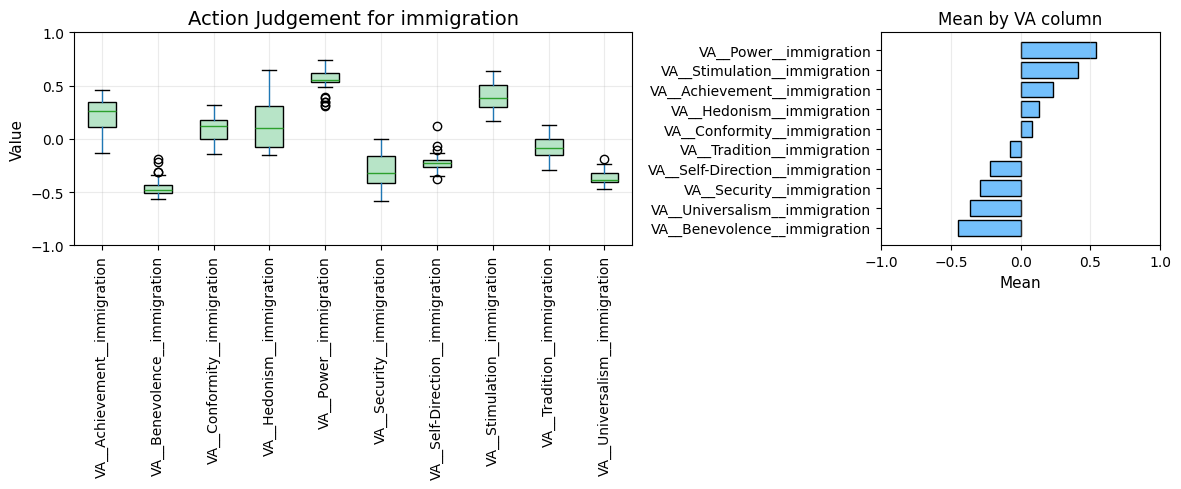

In [5]:
import re
import matplotlib.pyplot as plt

def _va_cols_for_topic(df, topic: str):
    # Get all VA columns for a given topic
    pattern = re.compile(rf"^VA__.*__{re.escape(topic)}$", flags=re.IGNORECASE)
    return [c for c in df.columns if pattern.match(c)]

def plot_va_topic(df, topic: str, figsize=(12, 5)):
    # Plot VA boxplot and mean by VA column for a given topic
    cols = _va_cols_for_topic(df, topic)
    if not cols:
        raise ValueError(f"No VA columns found for topic '{topic}'. Expected columns like 'VA__<Value>__{topic}'.")
    cols = sorted(cols)

    fig, axes = plt.subplots(1, 2, figsize=figsize, gridspec_kw={"width_ratios": [2, 1]})

    df[cols].boxplot(ax=axes[0], patch_artist=True, boxprops=dict(facecolor="#b7e4c7"))
    axes[0].set_title(f"Action Judgement for {topic}", fontsize=14)
    axes[0].set_ylabel("Value", fontsize=11)
    axes[0].tick_params(axis="x", rotation=90)
    axes[0].set_ylim(-1, 1)
    axes[0].grid(alpha=0.25)

    means = df[cols].mean(numeric_only=True).sort_values(ascending=False)
    axes[1].barh(means.index, means.values, color="#74c0fc", edgecolor="black")
    axes[1].set_title("Mean by VA column", fontsize=12)
    axes[1].set_xlabel("Mean", fontsize=11)
    axes[1].invert_yaxis()
    axes[1].set_xlim(-1, 1)
    axes[1].grid(axis="x", alpha=0.25)

    plt.tight_layout()
    plt.show()

plot_va_topic(value_system_df, "immigration")

### Notes: Immigration is good for the economony Action
- Medium-Strength (+/- 0.5) matching Schwartz Values
    - Self-Direction, Stimulation, Power, Benevolence, Universalism

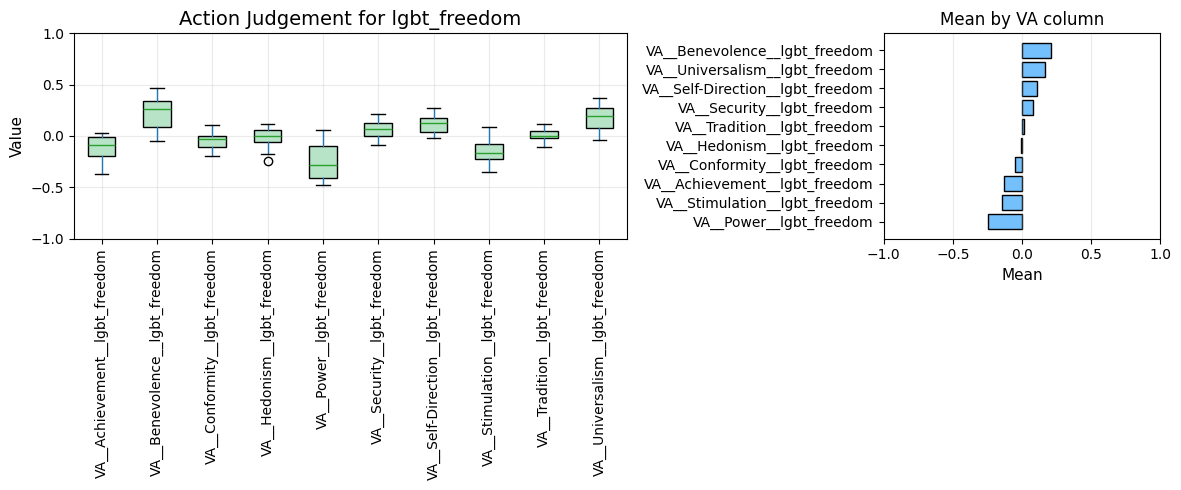

In [6]:
plot_va_topic(value_system_df, "lgbt_freedom")

### Notes: LGBT Rights Action
- Low-Strength correlation between values and actions, with a few agents having stronger correlations.
- No overall large trend.

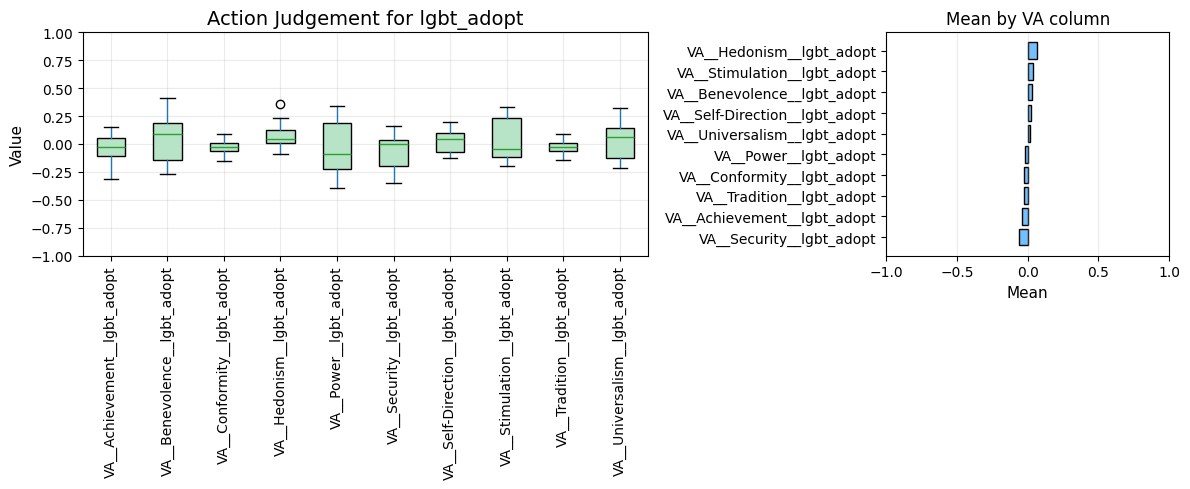

In [7]:
plot_va_topic(value_system_df, "lgbt_adopt")


### Notes: LGBT Adoption Action
- Low-Strength correlation with no extreme positions within the entire group.

### K-Means clustering/PCA analysis to find clusters of agents with similar action judgements
- Here we are looking to find distinct clusters. An ideal scenario would be i) one large cluster, with a small opposing cluster ii) two strongly opposing clusters of similar size. iii) No clear clusters.

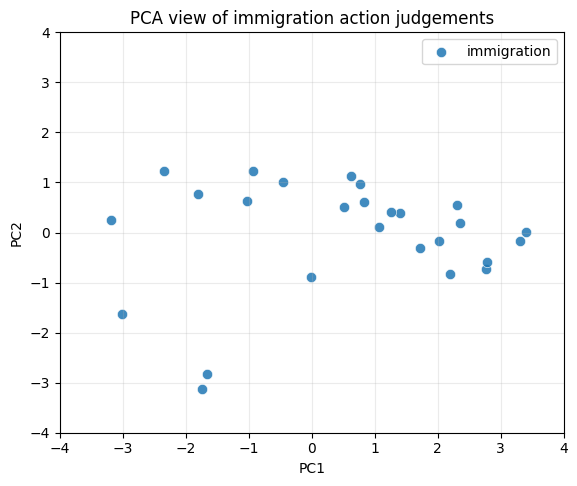

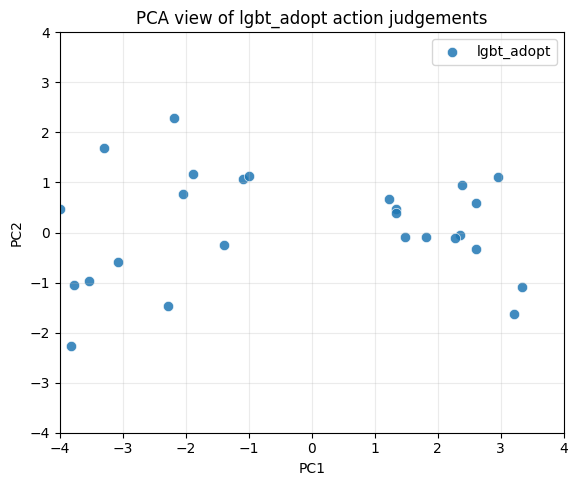

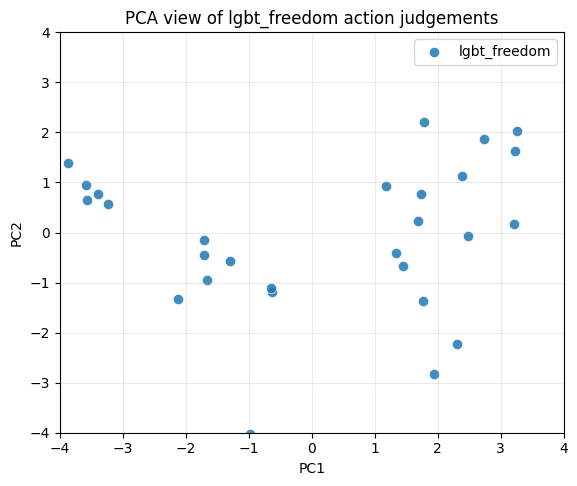

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def _va_cols_for_action(df: pd.DataFrame, action: str):
    suffix = f"__{action}"
    return [c for c in df.columns if c.startswith("VA__") and c.endswith(suffix)]

def PCA_per_action(df, actions=("immigration", "lgbt_adopt", "lgbt_freedom")):
    for action in actions:
        cols = sorted(_va_cols_for_action(df, action))
        scaler = StandardScaler()
        # take col data, and scale between 0-1, std 1, for PCA
        X = df[cols].to_numpy(dtype=float)
        X = scaler.fit_transform(X)
        pca_output = PCA(n_components=2).fit_transform(X)

        plt.figure(figsize=(6.5, 5.2))
        plt.scatter(pca_output[:, 0], pca_output[:, 1], s=55, alpha=0.85, edgecolor="white", linewidth=0.5, label=action)
        plt.title(f"PCA view of {action} action judgements")
        plt.xlabel("PC1")
        plt.ylabel("PC2")
        plt.xlim(-4, 4)
        plt.ylim(-4, 4)
        plt.grid(alpha=0.25)
        plt.legend(frameon=True)

PCA_per_action(value_system_df)

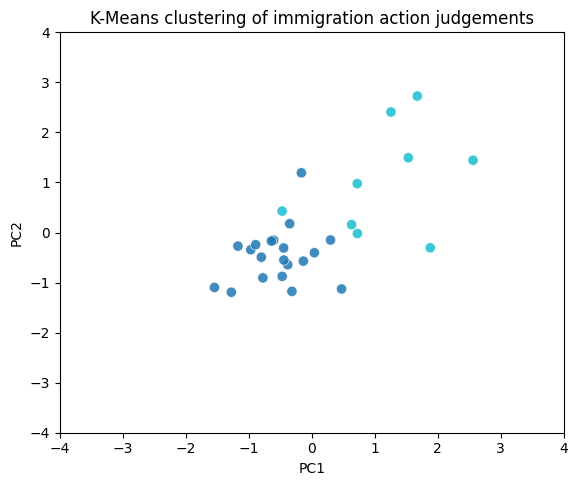

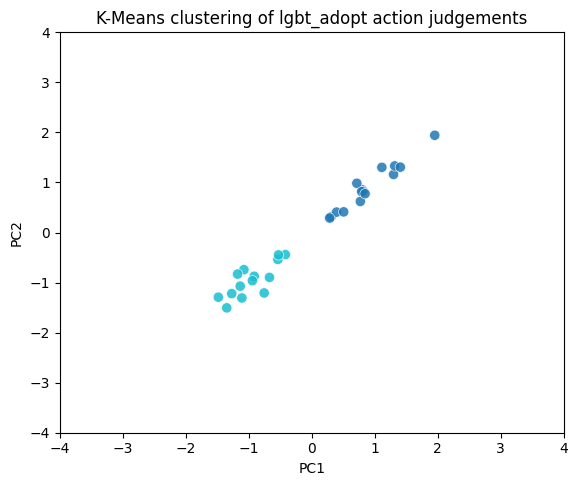

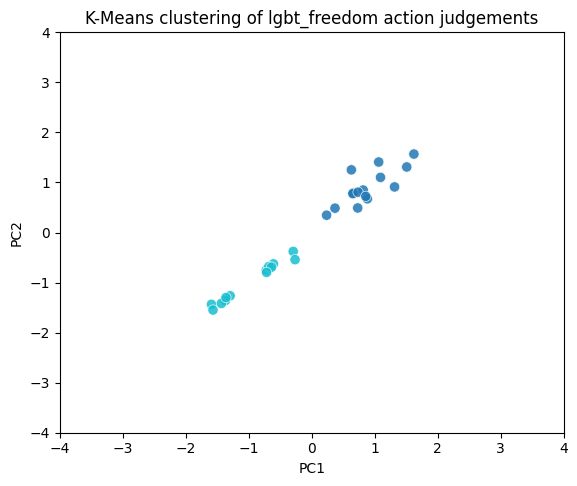

In [11]:
## K Means Clustering per action
import seaborn as sns

def k_means_actions(df, actions=("immigration", "lgbt_adopt", "lgbt_freedom")):
    for action in actions:
        cols = _va_cols_for_action(df, action)
        X = df[cols].to_numpy(dtype=float)
        scaler = StandardScaler()
        X = scaler.fit_transform(X)
        kmeans = KMeans(n_clusters=2, random_state=0).fit_predict(X)
        ## Have two plots, one showing the clusters, another showing the decisions made by each cluster
        ## Decision is calculated as the sum of each value judgement multiplied by the associated preference for a value

        plt.figure(figsize=(6.5, 5.2))
        plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, cmap="tab10", s=55, alpha=0.85, edgecolor="white", linewidth=0.5, label=action)
        plt.title(f"K-Means clustering of {action} action judgements")
        plt.xlabel("PC1")
        plt.ylabel("PC2")
        plt.xlim(-4,4)
        plt.ylim(-4, 4)


        sns.boxplot(x= means.labels_)

k_means_actions(value_system_df)


### Step 3: Connection between principles and personal values

### Step 4: Correlation with real support/disagreement and decision made by an agent's PVS